In [10]:
import autogen
autogen.__version__

'0.14.0'

In [11]:
#!pip install autogen-agentchat[gemini]~=0.2
#!pip install ag2[gemini]
#!pip install chromadb==0.5.1
#!pip install google-generativeai == 0.8.4
#!pip install vertexai == 1.71.1
#ag2 ==0.7.3
#autogen-agentchat ==  0.4.3
#python  3.11.11

In [23]:
import agentops
agentops.init("f837b665-8c48-4d93-85f3-c34f1dc93fcf")

In [13]:
from pathlib import Path

from autogen import ConversableAgent
from autogen.coding import  CodeBlock, LocalCommandLineCodeExecutor
work_dir = Path("coding")
work_dir.mkdir(exist_ok=True)

executor = LocalCommandLineCodeExecutor(work_dir=work_dir)

#Agent 1
code_executor_agent = ConversableAgent(
    name="code_executor_agent",
    llm_config=False,
    code_execution_config={
        "executor": executor,
    },
    human_input_mode="NEVER",
)

In [ ]:
# The code writer agent's system message is to instruct the LLM on how to
# use the Jupyter code executor with IPython kernel.
code_writer_system_message = """
You have been given coding capability to solve tasks using Python code.
In the following cases, suggest python code (in a python coding block) or shell script (in a sh coding block) for the user to execute.
    1. When you need to collect info, use the code to output the info you need, for example, browse or search the web, download/read a file, 
    print the content of a webpage or a file, get the current date/time, check the operating system. After sufficient info is printed and the 
    task is ready to be solved based on your language skill, you can solve the task by yourself.
    2. When you need to perform some task with code, use the code to perform the task and output the result. Finish the task smartly.
Solve the task step by step if you need to. If a plan is not provided, explain your plan first. Be clear which step uses code, and which step uses your 
language skill.When using code, you must indicate the script type in the code block. The user cannot provide any other feedback or perform any other 
action beyond executing the code you suggest. The user can't modify your code. So do not suggest incomplete code which requires users to modify. 
Don't use a code block if it's not intended to be executed by the user.
If you want the user to save the code in a file before executing it, put # filename: <filename> inside the code block as the first line. Don't include multiple code blocks in one response. Do not ask users to copy and paste the result. Instead, use 'print' function for the output when relevant. Check the execution result returned by the user.
"""

import os

#Agent 2

code_writer_agent = ConversableAgent(
    "code_writer",
    system_message=code_writer_system_message,
    llm_config={"config_list": [{"model": "gemini-2.5-flash", "api_key":"","api_type": "google"}]},
    code_execution_config=False,  # Turn off code execution for this agent.
    max_consecutive_auto_reply=2,
    human_input_mode="NEVER",)

In [15]:
import pprint

chat_result = code_executor_agent.initiate_chat(
    code_writer_agent, message=" write python code for permutation for the word ALGEbRA. use optimised way to calculate it .I want final result count."
)

pprint.pprint(chat_result)

code_executor_agent (to code_writer):

 write python code for permutation for the word ALGEbRA. use optimised way to calculate it .I want final result count.

--------------------------------------------------------------------------------
code_writer (to code_executor_agent):

To calculate the number of unique permutations for the word "ALGEbRA", we first need to count the total number of letters and the occurrences of each distinct letter.

The word is "ALGEbRA".
Total number of letters (n) = 7.
Letter counts:
*   A: 2 times
*   L: 1 time
*   G: 1 time
*   E: 1 time
*   b: 1 time
*   R: 1 time

The formula for permutations with repetitions is n! / (n1! * n2! * ... * nk!), where n is the total number of items, and n1, n2, ..., nk are the frequencies of each distinct item.

In this case, the number of permutations is 7! / (2! * 1! * 1! * 1! * 1! * 1!).
This simplifies to 7! / 2!.

Here's the Python code to calculate this:

```python
import math

# The word is ALGEbRA
word = "ALGEbRA"



In [16]:
import pprint

chat_result = code_executor_agent.initiate_chat(
    code_writer_agent, message="""Write optimized Python code to calculate the number of unique permutations of the word 'ALGEBRA.'
    For example, the word 'ALGEbRA' should have 2520 unique permutations. Use efficient logic to compute the result and verify the output using 
    the word 'ALGEBRA.' The code should only return the final permutation count.""")
pprint.pprint(chat_result)
#agentops.end_session("Success")

code_executor_agent (to code_writer):

Write optimized Python code to calculate the number of unique permutations of the word 'ALGEBRA.'
    For example, the word 'ALGEbRA' should have 2520 unique permutations. Use efficient logic to compute the result and verify the output using 
    the word 'ALGEBRA.' The code should only return the final permutation count.

--------------------------------------------------------------------------------
code_writer (to code_executor_agent):

To calculate the number of unique permutations of a word, we use the formula:
`n! / (n1! * n2! * ... * nk!)`
where `n` is the total number of letters in the word, and `n1, n2, ..., nk` are the frequencies of each unique repeated letter.

For the word 'ALGEBRA':
1. Total letters (n) = 7
2. Letter frequencies:
   - A: 2
   - L: 1
   - G: 1
   - E: 1
   - B: 1
   - R: 1

So, the calculation will be `7! / (2! * 1! * 1! * 1! * 1! * 1!) = 7! / 2!`.

The following Python code implements this logic efficiently using `m

In [17]:
dir(chat_result)


['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'chat_history',
 'chat_id',
 'cost',
 'human_input',
 'summary']

In [18]:
chat_result.chat_history

[{'content': "Write optimized Python code to calculate the number of unique permutations of the word 'ALGEBRA.'\n    For example, the word 'ALGEbRA' should have 2520 unique permutations. Use efficient logic to compute the result and verify the output using \n    the word 'ALGEBRA.' The code should only return the final permutation count.",
  'role': 'assistant',
  'name': 'code_executor_agent'},
 {'content': 'To calculate the number of unique permutations of a word, we use the formula:\n`n! / (n1! * n2! * ... * nk!)`\nwhere `n` is the total number of letters in the word, and `n1, n2, ..., nk` are the frequencies of each unique repeated letter.\n\nFor the word \'ALGEBRA\':\n1. Total letters (n) = 7\n2. Letter frequencies:\n   - A: 2\n   - L: 1\n   - G: 1\n   - E: 1\n   - B: 1\n   - R: 1\n\nSo, the calculation will be `7! / (2! * 1! * 1! * 1! * 1! * 1!) = 7! / 2!`.\n\nThe following Python code implements this logic efficiently using `math.factorial` and `collections.Counter`.\n\n```pytho

In [19]:
chat_result.chat_id

205537567195359157518437951585075222822

In [20]:
chat_result.cost

{'usage_including_cached_inference': {'total_cost': 0.0028417,
  'gemini-2.5-flash': {'cost': 0.0028417,
   'prompt_tokens': 2539,
   'completion_tokens': 832,
   'total_tokens': 3371}},
 'usage_excluding_cached_inference': {'total_cost': 0.0028417,
  'gemini-2.5-flash': {'cost': 0.0028417,
   'prompt_tokens': 2539,
   'completion_tokens': 832,
   'total_tokens': 3371}}}

In [21]:
chat_result.human_input

[]

In [22]:
chat_result.summary

''

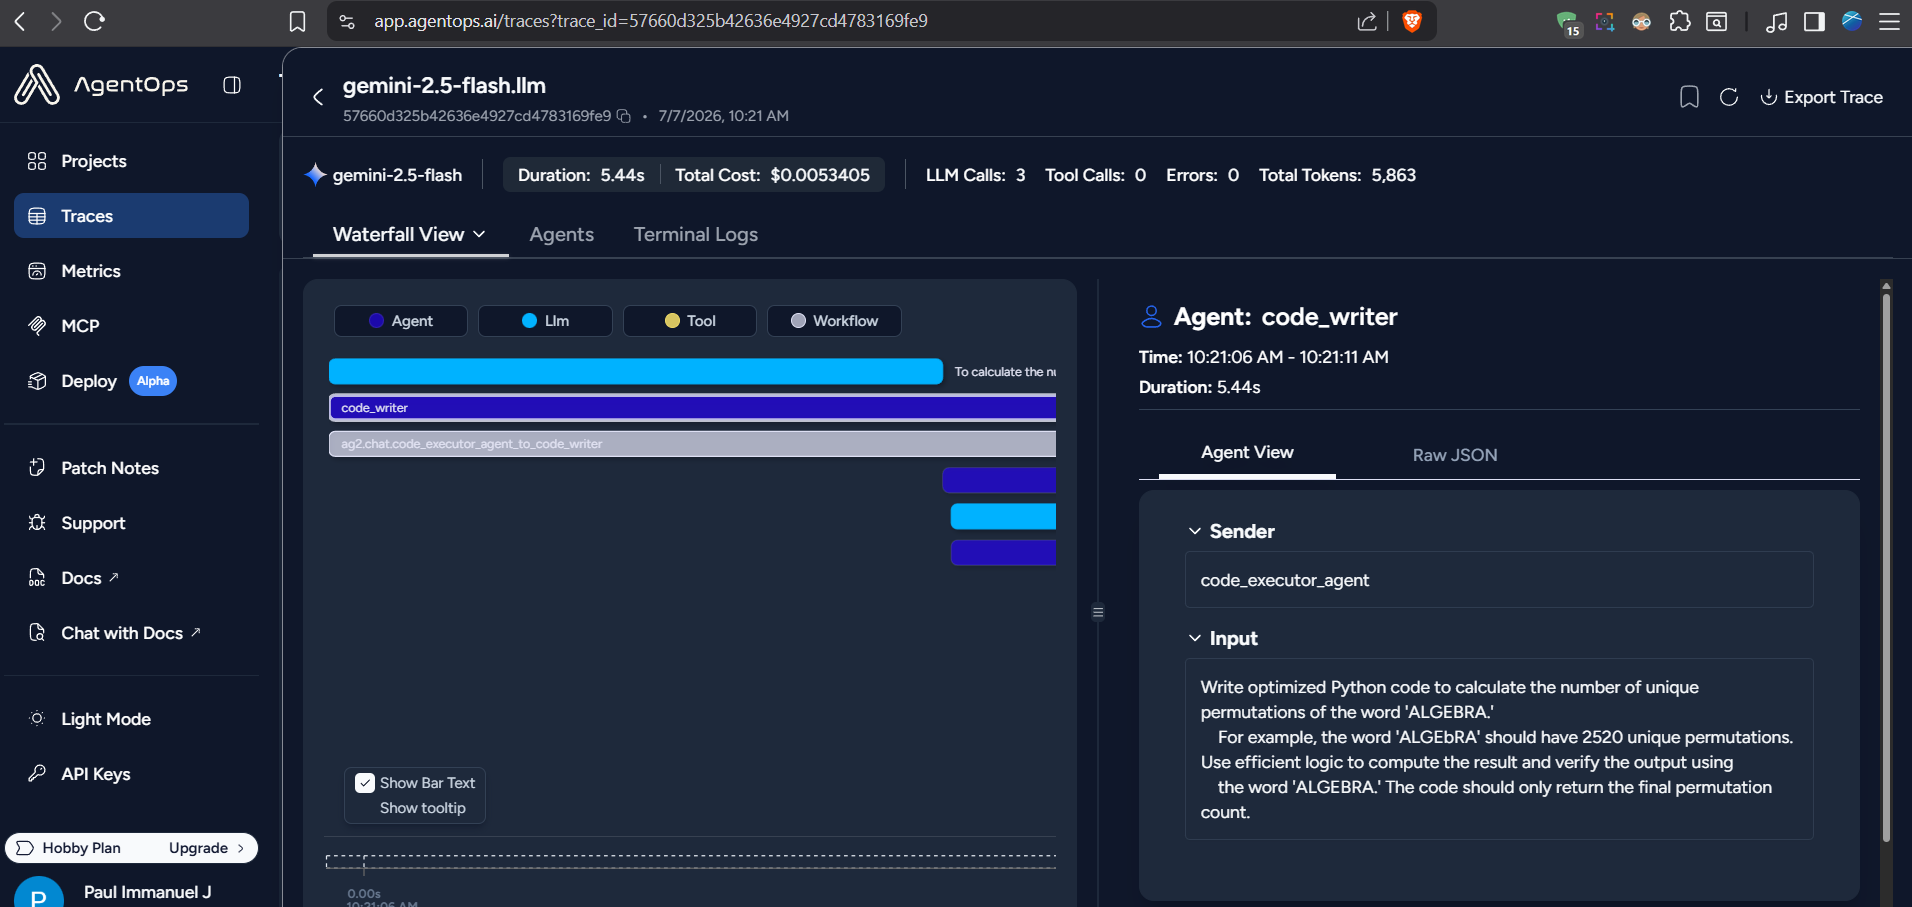

In [1]:
from IPython.display import Image, display
display(Image(filename='Gemini flash agent.png'))